In [23]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import FeaturizedMissingness
import SurvivalToDischarge

In [24]:
X, y = SurvivalToDischarge.load_data(sample_size=100000, icu_vitals=True, top_n_labs=230, top_n_drugs=0, top_n_procedures=0)

Returing 100000 patient records with 261 columns. y distribution: 
hospital_expire_flag
0    0.97966
1    0.02034
Name: proportion, dtype: float64


In [25]:
# 80/20 train-test, need to switch to train-validate-test once were comparing models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (80000, 261), Test: (20000, 261)


In [26]:
X.head(20)

,los_hours,anchor_age,gender_female,meanbp_systolic,meanbp_diastolic,maxbp_systolic,maxbp_diastolic,minbp_systolic,minbp_diastolic,result_value_x,...,admission_location_WALK-IN/SELF REFERRAL,insurance_Medicare,insurance_No charge,insurance_Other,insurance_Private,race_BLACK,race_HISPANIC/LATINO,race_NATIVE AMERICAN/ALASKA NATIVE,race_UNKNOWN OR MULTIPLE,race_WHITE
0,135.316667,47,1,127.833333,73.250000,152.0,89.0,104.0,59.0,126.000000,...,1,0,0,0,1,0,0,0,0,1
1,92.466667,59,1,123.177778,74.888889,151.0,93.0,80.0,52.0,166.219512,...,0,0,0,0,1,1,0,0,0,0
2,89.916667,76,0,149.833333,59.500000,177.0,68.0,113.0,50.0,157.715000,...,0,1,0,0,0,0,0,0,0,1
3,5.266667,31,0,127.833333,73.250000,152.0,89.0,104.0,59.0,171.700000,...,0,0,0,0,0,0,1,0,0,0
4,25.466667,74,1,145.500000,59.500000,176.0,80.0,122.0,36.0,148.657895,...,0,1,0,0,0,0,0,0,0,1
5,9.433333,47,0,127.833333,73.250000,152.0,89.0,104.0,59.0,171.700000,...,0,0,0,1,0,0,1,0,0,0
6,15.533333,62,1,121.800000,69.200000,138.0,71.0,113.0,67.0,171.700000,...,0,0,0,0,1,0,0,0,0,1
7,78.033333,31,1,114.000000,70.750000,120.0,80.0,108.0,60.0,171.700000,...,0,0,0,0,1,1,0,0,0,0
8,60.633333,89,1,155.701754,68.719298,214.0,90.0,104.0,47.0,160.765455,...,0,1,0,0,0,0,0,0,0,1
9,62.233333,48,1,112.000000,78.200000,128.0,84.0,104.0,74.0,171.700000,...,0,0,0,0,1,0,0,0,1,0


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [28]:
model = LogisticRegression(C=0.2, class_weight='balanced', max_iter=10000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       18100     1493   (specificity 0.924)
  Actual 1          48      359   (sensitivity 0.882)

TPR (sensitivity):  0.882
FPR (fall-out):     0.076
Precision:          0.194
ROC-AUC:            0.963

              precision    recall  f1-score   support

    Survived       1.00      0.92      0.96     19593
        Died       0.19      0.88      0.32       407

    accuracy                           0.92     20000
   macro avg       0.60      0.90      0.64     20000
weighted avg       0.98      0.92      0.95     20000



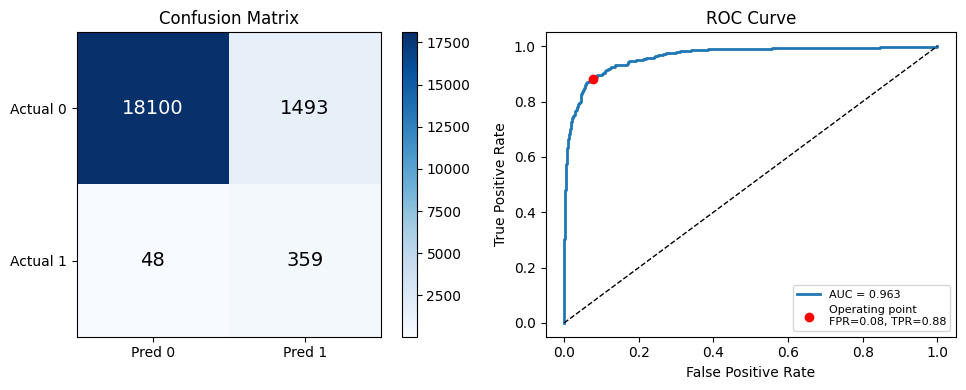

In [29]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

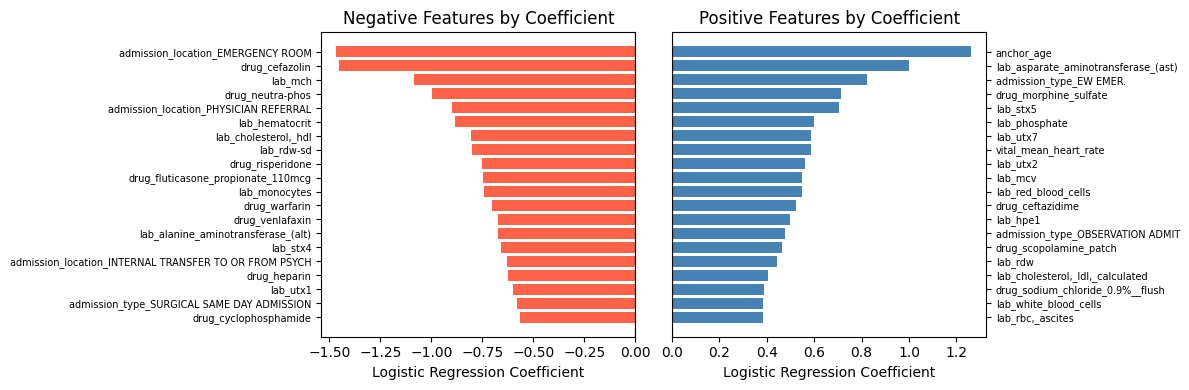

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Top feature coefficients
coef_series = pd.Series(model.coef_[0], index=X.columns)
top__neg_coef = coef_series[coef_series != 0].sort_values(ascending=True).head(20)
signed_top = coef_series[top__neg_coef.index]
axes[0].barh(signed_top.index[::-1], signed_top.values[::-1], color='tomato')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].set_title('Negative Features by Coefficient')
axes[0].tick_params(axis='y', labelsize=7)

coef_series = pd.Series(model.coef_[0], index=X.columns)
top_pos_coef = coef_series[coef_series != 0].sort_values(ascending=False).head(20)
signed_top = coef_series[top_pos_coef.index]
axes[1].barh(signed_top.index[::-1], signed_top.values[::-1], color='steelblue')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].set_title('Positive Features by Coefficient')
axes[1].tick_params(axis='y', labelsize=7)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# Logistic regression with L1 penalty and 20 different regularization strengths
model = LogisticRegressionCV(
    Cs=np.logspace(-4, 1, 20),
    cv=5,
    l1_ratios=(1,),
    solver='saga',
    max_iter=800,
    tol=1e-4,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    class_weight='balanced'
)
model.fit(X_train_scaled, y_train)

best_C = model.C_[0]
print(f"Best C: {best_C:.6f}")
print(f"Non-zero coefficients: {np.sum(model.coef_[0] != 0)} / {len(model.coef_[0])}")

c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


convergence after 648 epochs took 554 seconds
convergence after 665 epochs took 568 seconds
convergence after 686 epochs took 600 seconds
convergence after 696 epochs took 604 seconds
max_iter reached after 684 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 76 epochs took 67 seconds
convergence after 109 epochs took 96 seconds
convergence after 340 epochs took 295 seconds
convergence after 343 epochs took 303 seconds
convergence after 350 epochs took 305 seconds
convergence after 98 epochs took 85 seconds
convergence after 392 epochs took 346 seconds
convergence after 97 epochs took 85 seconds
convergence after 99 epochs took 88 seconds
convergence after 99 epochs took 87 seconds
convergence after 141 epochs took 123 seconds
convergence after 179 epochs took 155 seconds
convergence after 227 epochs took 220 seconds
max_iter reached after 726 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 741 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 282 epochs took 284 seconds
max_iter reached after 765 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 757 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 354 epochs took 349 seconds
max_iter reached after 789 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 779 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 769 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 767 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 332 epochs took 316 seconds
convergence after 795 epochs took 818 seconds
convergence after 441 epochs took 426 seconds
convergence after 694 epochs took 648 seconds
max_iter reached after 762 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 473 epochs took 441 seconds
convergence after 410 epochs took 385 seconds
convergence after 532 epochs took 497 seconds
max_iter reached after 794 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 498 epochs took 475 seconds
max_iter reached after 743 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 776 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 600 epochs took 568 seconds
convergence after 372 epochs took 357 seconds
convergence after 649 epochs took 644 seconds
max_iter reached after 816 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 783 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 779 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 780 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 802 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 827 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 801 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 797 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 799 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 814 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 852 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 819 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 809 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 814 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 822 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 843 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 826 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 826 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 819 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 839 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 850 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 847 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 832 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 834 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 842 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 859 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 845 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 840 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 847 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 541 epochs took 585 seconds
max_iter reached after 855 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 117 epochs took 131 seconds
convergence after 64 epochs took 73 seconds
convergence after 36 epochs took 41 seconds
max_iter reached after 835 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 829 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 830 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 817 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 446 epochs took 468 seconds
convergence after 157 epochs took 169 seconds
convergence after 89 epochs took 98 seconds
max_iter reached after 833 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 832 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 50 epochs took 58 seconds
convergence after 26 epochs took 31 seconds


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed: 179.5min remaining: 269.3min


max_iter reached after 805 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 745 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 755 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 759 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 95 epochs took 92 seconds
convergence after 49 epochs took 47 seconds
convergence after 552 epochs took 512 seconds
convergence after 53 epochs took 46 seconds
convergence after 29 epochs took 27 seconds
max_iter reached after 675 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 459 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 464 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 218.1min finished


convergence after 196 epochs took 125 seconds
Best C: 0.003793
Non-zero coefficients: 272 / 660


In [10]:
import joblib
joblib.dump(model, 'results/featurized_missingness_model.joblib')

['results/featurized_missingness_model.joblib']

In [11]:
coef_series = pd.Series(model.coef_[0], index=X.columns)
coef_series = coef_series.sort_values()
coef_series.to_csv('results/featurized_missingness_series.csv')

In [12]:
drug_coef = coef_series[coef_series.index.str.startswith('drug_')].sort_values()
lab_coef = coef_series[coef_series.index.str.startswith('lab_')].sort_values()
procedure_coef = coef_series[coef_series.index.str.startswith('procedure_')].sort_values()

print(f"Non-zero drugs: {np.sum(drug_coef != 0)} / {len(drug_coef)}")
print(f"Non-zero labs: {np.sum(lab_coef != 0)} / {len(lab_coef)}")
print(f"Non-zero procedures: {np.sum(procedure_coef != 0)} / {len(procedure_coef)}")

Non-zero drugs: 154 / 344
Non-zero labs: 74 / 211
Non-zero procedures: 21 / 55


Confusion matrix:
                Pred 0   Pred 1
  Actual 0       18780      813   (specificity 0.959)
  Actual 1          39      368   (sensitivity 0.904)

TPR (sensitivity):  0.904
FPR (fall-out):     0.041
Precision:          0.312
ROC-AUC:            0.984

              precision    recall  f1-score   support

    Survived       1.00      0.96      0.98     19593
        Died       0.31      0.90      0.46       407

    accuracy                           0.96     20000
   macro avg       0.65      0.93      0.72     20000
weighted avg       0.98      0.96      0.97     20000



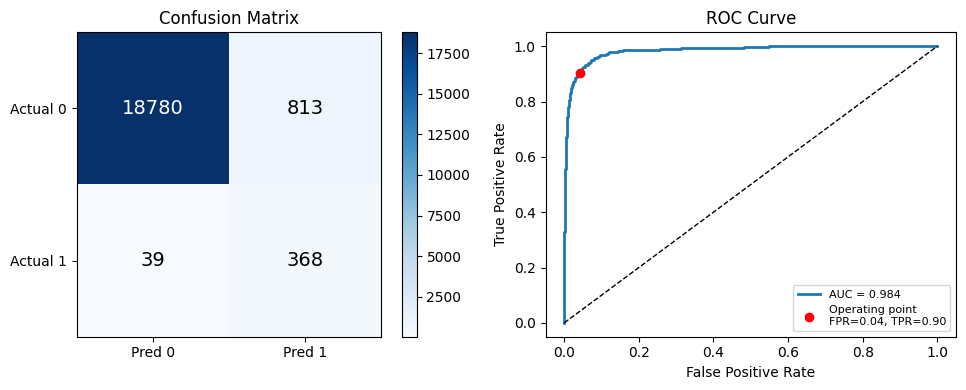

In [15]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

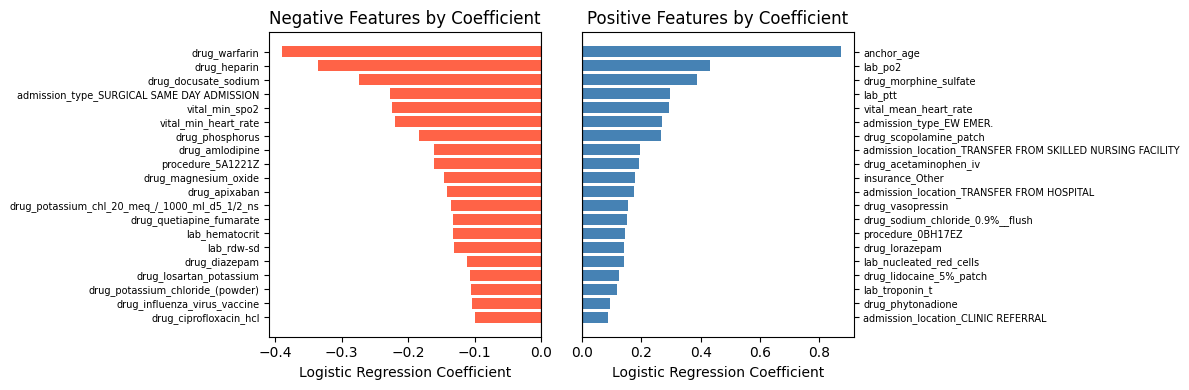

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Top feature coefficients
coef_series = pd.Series(model.coef_[0], index=X.columns)
top__neg_coef = coef_series[coef_series != 0].sort_values(ascending=True).head(20)
signed_top = coef_series[top__neg_coef.index]
axes[0].barh(signed_top.index[::-1], signed_top.values[::-1], color='tomato')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].set_title('Negative Features by Coefficient')
axes[0].tick_params(axis='y', labelsize=7)

coef_series = pd.Series(model.coef_[0], index=X.columns)
top_pos_coef = coef_series[coef_series != 0].sort_values(ascending=False).head(20)
signed_top = coef_series[top_pos_coef.index]
axes[1].barh(signed_top.index[::-1], signed_top.values[::-1], color='steelblue')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].set_title('Positive Features by Coefficient')
axes[1].tick_params(axis='y', labelsize=7)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()